Note: this notebook aims to run the pipeline of modeling, model_training, model_tuning and model_evaluation, and make conclusion in the end.

### 1. Data Loading

In [1]:
import pandas as pd
from CreditCardApproval.data import load_data

processed_df = load_data(return_type="processed")

In [2]:
# brief look
print("processed_df shape:", processed_df.shape)
processed_df.head()

processed_df shape: (36457, 18)


,ID,gender,own_car,own_realty,children_number,annual_income,own_work_phone,own_phone,own_email,family_size,age_years,is_unemployed,employed_years,income_type,education_level,family_status,housing_status,target
0,5008804,M,Y,Y,0,427500.0,1,0,0,2.0,32.867899,0,12.435318,Employed,Higher,Married,Rental,0
1,5008805,M,Y,Y,0,427500.0,1,0,0,2.0,32.867899,0,12.435318,Employed,Higher,Married,Rental,0
2,5008806,M,Y,Y,0,112500.0,0,0,0,2.0,58.792608,0,3.104723,Employed,Secondary,Married,Own_Home,0
3,5008808,F,N,Y,0,270000.0,0,1,1,1.0,52.320329,0,8.353183,Employed,Secondary,Single,Own_Home,0
4,5008809,F,N,Y,0,270000.0,0,1,1,1.0,52.320329,0,8.353183,Employed,Secondary,Single,Own_Home,0


In [3]:
print("Is ID unique:", processed_df["ID"].is_unique)
processed_df.info()

Is ID unique: True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               36457 non-null  int64  
 1   gender           36457 non-null  object 
 2   own_car          36457 non-null  object 
 3   own_realty       36457 non-null  object 
 4   children_number  36457 non-null  int64  
 5   annual_income    36457 non-null  float64
 6   own_work_phone   36457 non-null  int64  
 7   own_phone        36457 non-null  int64  
 8   own_email        36457 non-null  int64  
 9   family_size      36457 non-null  float64
 10  age_years        36457 non-null  float64
 11  is_unemployed    36457 non-null  int64  
 12  employed_years   36457 non-null  float64
 13  income_type      36457 non-null  object 
 14  education_level  36457 non-null  object 
 15  family_status    36457 non-null  object 
 16  housing_status   36457 non-null  object

***

### 2. Modeling

##### ① Specify X and y

In [4]:
from CreditCardApproval.modeling import make_X_y, summarize_target

X, y = make_X_y(processed_df)
summarize_target(y)

,count,proportion
target,,
0,35841,0.983103
1,616,0.016897


Review:

The target variable is highly imbalanced, which is typical in credit risk modeling. Instead of resampling the data, class imbalance is handled at the modeling stage by using class-weighted loss functions and appropriate evaluation metrics. Logistic regression applies balanced class weights, while LightGBM incorporates scale_pos_weight computed from the training data. Model performance is evaluated using AUC to ensure robustness under imbalance.

##### ② Configuration and feature schema

In [5]:
from CreditCardApproval.modeling import FINAL_SCHEMA, validate_schema

validate_schema(processed_df, FINAL_SCHEMA)

##### ③ Build up model pipeline

In [6]:
from CreditCardApproval.modeling import make_glm_pipeline, make_lgbm_pipeline

glm_pipe = make_glm_pipeline(
    schema=FINAL_SCHEMA,
    log_income=True,
    income_col="annual_income",
)
glm_pipe

,steps,"[('log_income', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,columns,['annual_income']
,add_suffix,True
,suffix,'_log1p'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


In [7]:
lgbm_pipe = make_lgbm_pipeline(
    schema=FINAL_SCHEMA,
    log_income=True,
    income_col="annual_income",
)
lgbm_pipe

,steps,"[('log_income', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,columns,['annual_income']
,add_suffix,True
,suffix,'_log1p'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


##### ④ Preview pipeline dimension

In [8]:
from CreditCardApproval.modeling import preview_pipeline_dimensions

glm_preview = preview_pipeline_dimensions(glm_pipe, X)
print("GLM model pipeline preview:")
glm_preview

GLM model pipeline preview:


{'n_features_after_preprocess': 26,
 'n_samples_preview': 2000,
 'preview_rows_used': 2000,
 'columns_after_fe_preview': ['gender',
  'own_car',
  'own_realty',
  'children_number',
  'annual_income',
  'own_work_phone',
  'own_phone',
  'own_email',
  'family_size',
  'age_years',
  'is_unemployed',
  'employed_years',
  'income_type',
  'education_level',
  'family_status',
  'housing_status',
  'annual_income_log1p']}

In [9]:
lgbm_preview = preview_pipeline_dimensions(lgbm_pipe, X)
print("LGBM model pipeline preview:")
lgbm_preview

LGBM model pipeline preview:


{'n_features_after_preprocess': 26,
 'n_samples_preview': 2000,
 'preview_rows_used': 2000,
 'columns_after_fe_preview': ['gender',
  'own_car',
  'own_realty',
  'children_number',
  'annual_income',
  'own_work_phone',
  'own_phone',
  'own_email',
  'family_size',
  'age_years',
  'is_unemployed',
  'employed_years',
  'income_type',
  'education_level',
  'family_status',
  'housing_status',
  'annual_income_log1p']}

Review:

The preview confirms that both the GLM and LGBM pipelines produce the same feature dimensionality after preprocessing. This indicates that feature engineering steps, including categorical encoding and numerical transformations, are applied consistently across models, ensuring a fair comparison in subsequent training and evaluation.

***

### 3. Model Training

In [10]:
from CreditCardApproval.model_training import split_data

X_train, X_val, y_train, y_val = split_data(X, y)

In [11]:
from CreditCardApproval.model_training import train_glm

glm_model, glm_auc = train_glm(X_train, y_train, X_val, y_val)
glm_auc

0.5612290723269905

In [12]:
from CreditCardApproval.model_training import train_lgbm

lgbm_model, lgbm_auc = train_lgbm(X_train, y_train, X_val, y_val)
lgbm_auc

[LightGBM] [Info] Number of positive: 493, number of negative: 28672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 896
[LightGBM] [Info] Number of data points in the train set: 29165, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016904 -> initscore=-4.063167
[LightGBM] [Info] Start training from score -4.063167


0.764123308690194

***

### 4. Hyperparameter Tuning

In [13]:
from CreditCardApproval.tuning import tune_glm, tune_lgbm
from sklearn.metrics import roc_auc_score

In [14]:
glm_best_model, glm_best_params = tune_glm(
    X_train,
    y_train,
    cv_splits=5,
)

glm_best_params

Fitting 5 folds for each of 4 candidates, totalling 20 fits


{'model__C': 0.1, 'model__penalty': 'l2'}

In [15]:
glm_val_proba = glm_best_model.predict_proba(X_val)[:, 1]
glm_val_auc = roc_auc_score(y_val, glm_val_proba)

glm_val_auc

0.5573902767901999

In [16]:
lgbm_best_model, lgbm_best_params = tune_lgbm(
    X_train,
    y_train,
    cv_splits=5,
)

lgbm_best_params

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 493, number of negative: 28672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 896
[LightGBM] [Info] Number of data points in the train set: 29165, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016904 -> initscore=-4.063167
[LightGBM] [Info] Start training from score -4.063167


{'model__learning_rate': 0.05,
 'model__n_estimators': 400,
 'model__num_leaves': 63}

In [17]:
lgbm_val_proba = lgbm_best_model.predict_proba(X_val)[:, 1]
lgbm_val_auc = roc_auc_score(y_val, lgbm_val_proba)

lgbm_val_auc

0.746239738168061

In [18]:
pd.DataFrame(
    {
        "Model": ["GLM (baseline)", "GLM (tuned)", "LGBM (baseline)", "LGBM (tuned)"],
        "Validation AUC": [
            glm_auc,
            glm_val_auc,
            lgbm_auc,
            lgbm_val_auc,
        ],
    }
)

,Model,Validation AUC
0,GLM (baseline),0.561229
1,GLM (tuned),0.557390
2,LGBM (baseline),0.764123
3,LGBM (tuned),0.746240


***

### 5. Model Evaluation & Comparison

In [19]:
from CreditCardApproval.evaluation import compare_models

summary = compare_models(
    models={
        "GLM (baseline)": glm_model,
        "GLM (tuned)": glm_best_model,
        "LGBM (baseline)": lgbm_model,
        "LGBM (tuned)": lgbm_best_model,
    },
    X=X_val,
    y=y_val,
    threshold=0.5,
)

summary

,threshold,auc,gini,ks,accuracy,precision,recall,f1,f2,tp,fp,tn,fn
model,,,,,,,,,,,,,
GLM (baseline),0.5,0.561229,0.122458,0.187208,0.983132,0.000000,0.000000,0.000000,0.000000,0,0,7169,123
GLM (tuned),0.5,0.557390,0.114781,0.159370,0.983132,0.000000,0.000000,0.000000,0.000000,0,0,7169,123
LGBM (baseline),0.5,0.764123,0.528247,0.448866,0.982172,0.360000,0.073171,0.121622,0.087041,9,16,7153,114
LGBM (tuned),0.5,0.746240,0.492479,0.452414,0.981624,0.392157,0.162602,0.229885,0.184162,20,31,7138,103


***

### 6. Visualization

##### ① ROC Curve

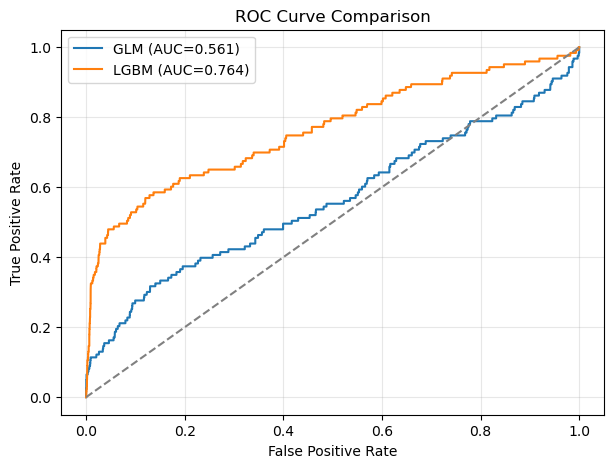

In [20]:
from CreditCardApproval.evaluation import plot_roc_curves

plot_roc_curves(
    models={
        "GLM": glm_model,
        "LGBM": lgbm_model,
    },
    X=X_val,
    y=y_val,
)

##### ② Confusion Matrix

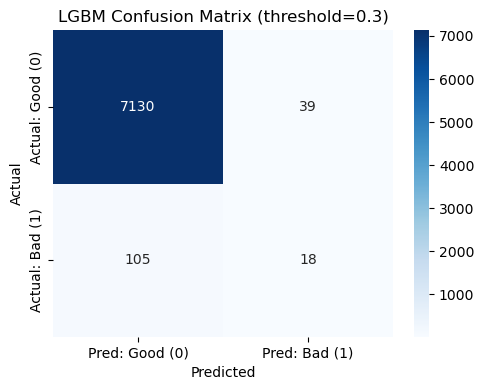

In [21]:
from CreditCardApproval.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    lgbm_model,
    X_val,
    y_val,
    threshold=0.3,
    title="LGBM Confusion Matrix (threshold=0.3)",
)

##### ③ Optimal Threshold

In [22]:
from CreditCardApproval.evaluation import find_optimal_threshold

# 1) get predicted probabilities
glm_proba = glm_model.predict_proba(X_val)[:, 1]
lgbm_proba = lgbm_model.predict_proba(X_val)[:, 1]

# 2) find optimal thresholds
glm_best_t, glm_thr_table = find_optimal_threshold(
    y_true=y_val,
    y_proba=glm_proba,
    metric="f2",
)

lgbm_best_t, lgbm_thr_table = find_optimal_threshold(
    y_true=y_val,
    y_proba=lgbm_proba,
    metric="f2",
)

glm_best_t, lgbm_best_t

(0.03, 0.06)

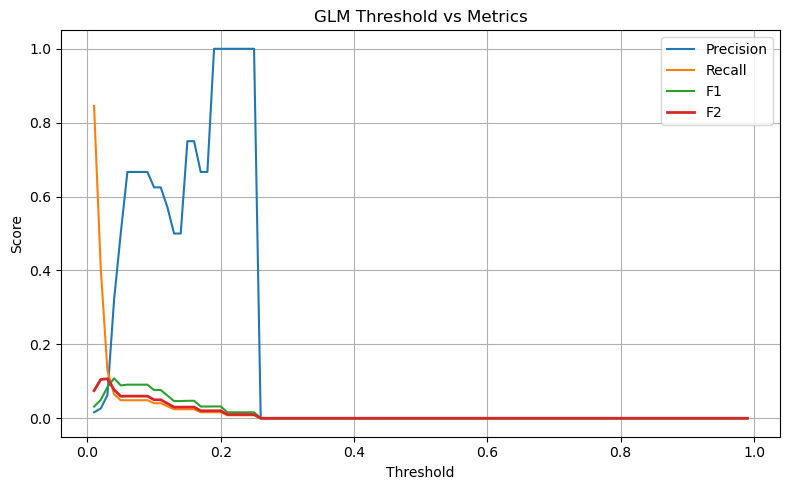

In [23]:
from CreditCardApproval.evaluation import plot_threshold_curves

plot_threshold_curves(
    y_true=y_val,
    y_proba=glm_proba,
    title="GLM Threshold vs Metrics"
)

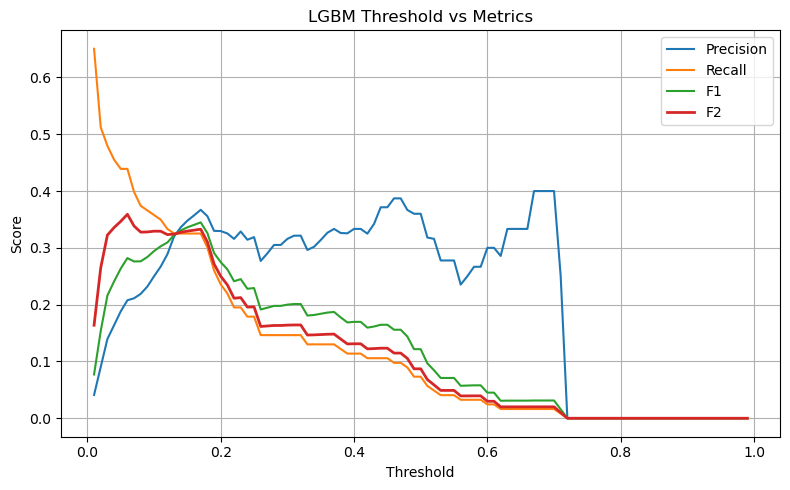

In [24]:
from CreditCardApproval.evaluation import plot_threshold_curves

plot_threshold_curves(
    y_true=y_val,
    y_proba=lgbm_proba,
    title="LGBM Threshold vs Metrics"
)

In [25]:
from CreditCardApproval.evaluation import compare_models

summary_opt = compare_models(
    models={
        "GLM (t=0.5)": glm_model,
        "GLM (opt F2)": glm_model,
        "LGBM (t=0.5)": lgbm_model,
        "LGBM (opt F2)": lgbm_model,
    },
    X=X_val,
    y=y_val,
    threshold={
        "GLM (t=0.5)": 0.5,
        "GLM (opt F2)": glm_best_t,
        "LGBM (t=0.5)": 0.5,
        "LGBM (opt F2)": lgbm_best_t,
    },
)

summary_opt

,threshold,auc,gini,ks,accuracy,precision,recall,f1,f2,tp,fp,tn,fn
model,,,,,,,,,,,,,
GLM (t=0.5),0.50,0.561229,0.122458,0.187208,0.983132,0.000000,0.000000,0.000000,0.000000,0,0,7169,123
GLM (opt F2),0.03,0.561229,0.122458,0.187208,0.952276,0.062257,0.130081,0.084211,0.106809,16,241,6928,107
LGBM (t=0.5),0.50,0.764123,0.528247,0.448866,0.982172,0.360000,0.073171,0.121622,0.087041,9,16,7153,114
LGBM (opt F2),0.06,0.764123,0.528247,0.448866,0.962287,0.207692,0.439024,0.281984,0.359043,54,206,6963,69


##### ④ Compare predicted and actual data

,bin,n,actual_rate,avg_pred,min_pred,max_pred,model
0,"(-0.0009771, 0.00964]",730,0.026027,0.007896,0.000023,0.009640,GLM
1,"(0.00964, 0.0116]",729,0.009602,0.010663,0.009641,0.011565,GLM
2,"(0.0116, 0.0131]",729,0.009602,0.012369,0.011566,0.013109,GLM
3,"(0.0131, 0.0145]",729,0.015089,0.013817,0.013114,0.014516,GLM
4,"(0.0145, 0.0159]",730,0.015068,0.015251,0.014519,0.015948,GLM
5,"(0.0159, 0.0173]",729,0.012346,0.016595,0.015955,0.017278,GLM
6,"(0.0173, 0.0191]",728,0.009615,0.018159,0.017281,0.019091,GLM
7,"(0.0191, 0.0215]",730,0.008219,0.020197,0.019093,0.021492,GLM
8,"(0.0215, 0.0252]",728,0.017857,0.023157,0.021494,0.025175,GLM
9,"(0.0252, 0.251]",730,0.045205,0.031089,0.025231,0.250668,GLM


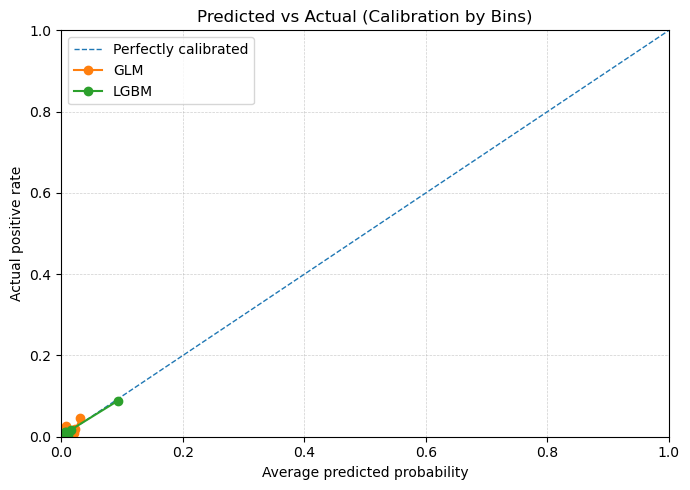

In [26]:
from CreditCardApproval.evaluation import plot_predicted_vs_actual

cal_table = plot_predicted_vs_actual(
    models={"GLM": glm_model, "LGBM": lgbm_model},
    X=X_val,
    y=y_val,
    n_bins=10,
    strategy="quantile",
)

cal_table

##### ⑤ Feature importance

In [27]:
from CreditCardApproval.evaluation import (
    get_glm_feature_importance,
    get_lgbm_feature_importance,
)

glm_imp = get_glm_feature_importance(glm_model, top_k=10)
lgbm_imp = get_lgbm_feature_importance(lgbm_model, top_k=10)

print(f"Feature importance of GLM:\n", glm_imp)
print(f"\nFeature importance of LGBM:\n", lgbm_imp)

Feature importance of GLM:
                                  feature      coef  abs_coef
0                       num__family_size  2.050835  2.050835
1             cat__family_status_Married -1.912073  1.912073
2                   num__children_number -1.585867  1.585867
3  cat__family_status_Previously_Married  0.703089  0.703089
4              cat__family_status_Single  0.608997  0.608997
5              cat__income_type_Employed -0.499853  0.499853
6                      cat__own_realty_Y -0.464347  0.464347
7                          cat__gender_F -0.442056  0.442056
8       cat__housing_status_With_Parents -0.416136  0.416136
9                         cat__own_car_Y -0.377033  0.377033

Feature importance of LGBM:
                 feature  importance
0        num__age_years        2736
1   num__employed_years        2035
2    num__annual_income        1704
3      num__family_size         289
4  num__children_number         234
5        num__own_phone         190
6         cat__gend

***

### 7. Conclusion